#### DBSCAN
Density Based Special Clustering of Applications with Noise

It is usefull for nasted clustering

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../data/chanels.csv")
df = df[df["rank"] <= 500]
df.head()

,rank,Youtuber,subscribers,video views,video count,category,started
0,1,T-Series,"222,000,000","198,459,090,822","17,317",Music,2006
1,2,YouTube Movies,"154,000,000",0,0,Film & Animation,2015
2,3,Cocomelon - Nursery Rhymes,"140,000,000","135,481,339,848",786,Education,2006
3,4,SET India,"139,000,000","125,764,252,686","91,271",Shows,2006
4,5,Music,"116,000,000",0,0,NaN,2013


In [4]:
df.shape

(500, 7)

In [5]:
df = df.drop(columns=["rank","Youtuber","video count","category","started"])
df.head()

,subscribers,video views
0,"222,000,000","198,459,090,822"
1,"154,000,000",0
2,"140,000,000","135,481,339,848"
3,"139,000,000","125,764,252,686"
4,"116,000,000",0


In [11]:

subs = []
views = []
for i in df["subscribers"]:
    x = str.replace(i,',','')
    subs.append(int(x)/1000000)

for i in df["video views"]:
    x = str.replace(i,',','')
    views.append(int(x)/10000000)

df["subscribers"] = subs
df["video views"] = views

In [13]:
df["video views"] = np.ceil(df['video views'])
df.head()

,subscribers,video views
0,222.0,19846.0
1,154.0,0.0
2,140.0,13549.0
3,139.0,12577.0
4,116.0,0.0


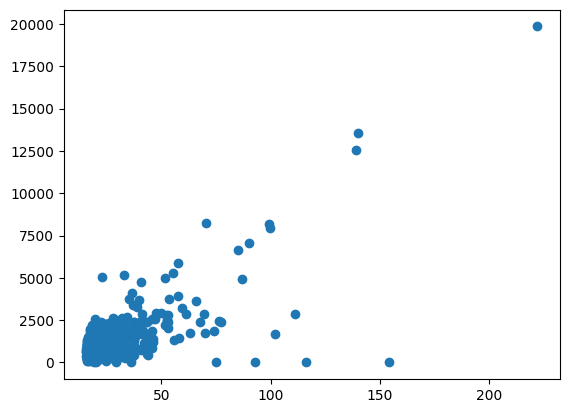

In [14]:
plt.scatter(df["subscribers"],df["video views"])

#### I could not realize the number of clusters here, So let's do elbow

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\si

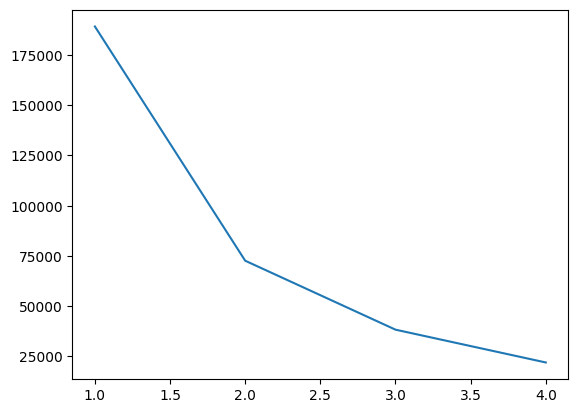

In [16]:
sse = []
for k in range(1,5):
    KM = KMeans(k)
    KM.fit(df[["subscribers"]],df[["video views"]])
    sse.append(KM.inertia_)

plt.plot(range(1,5),sse)

In [60]:
DB = DBSCAN(min_samples=5,eps=5)

In [61]:
DB.fit(df[["subscribers"]],df[["video views"]])

DBSCAN(eps=5)

In [62]:
predict = DB.fit_predict(df[["subscribers"]],df[["video views"]])

In [63]:
predict

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [64]:
df["cluster"] = predict

In [65]:
df.head()

,subscribers,video views,cluster
0,222.0,19846.0,-1
1,154.0,0.0,-1
2,140.0,13549.0,-1
3,139.0,12577.0,-1
4,116.0,0.0,-1


In [66]:
df1 = df[df["cluster"] == -1]
df2 = df[df["cluster"] == 0]

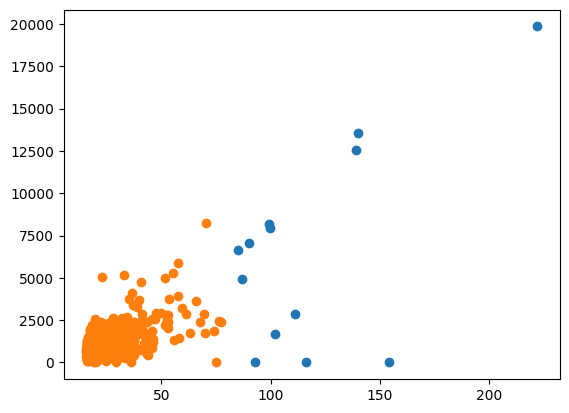

In [67]:
plt.scatter(df1["subscribers"],df1["video views"])
plt.scatter(df2["subscribers"],df2["video views"])